### limpeza de dados

In [53]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [54]:
mat = pd.read_csv("student-mat.csv", sep=";")
por = pd.read_csv("student-por.csv", sep=";")

print("matematica:", mat.shape)
print("portugues:", por.shape)

matematica: (395, 33)
portugues: (649, 33)


In [55]:
chaves_merge = [
    "school", "sex", "age", "address", "famsize", "Pstatus",
    "Medu", "Fedu", "Mjob", "Fjob", "reason", "nursery", "internet"
]

df = pd.merge(mat, por, on=chaves_merge, suffixes=("_mat", "_por"))

print("Tamanho da base depois do merge:", df.shape)
df.head()

Tamanho da base depois do merge: (382, 53)


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,reason,guardian_mat,traveltime_mat,studytime_mat,failures_mat,schoolsup_mat,famsup_mat,paid_mat,activities_mat,nursery,higher_mat,internet,romantic_mat,famrel_mat,freetime_mat,goout_mat,Dalc_mat,Walc_mat,health_mat,absences_mat,G1_mat,G2_mat,G3_mat,guardian_por,traveltime_por,studytime_por,failures_por,schoolsup_por,famsup_por,paid_por,activities_por,higher_por,romantic_por,famrel_por,freetime_por,goout_por,Dalc_por,Walc_por,health_por,absences_por,G1_por,G2_por,G3_por
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,course,mother,2,2,0,yes,no,no,no,yes,yes,no,no,4,3,4,1,1,3,6,5,6,6,mother,2,2,0,yes,no,no,no,yes,no,4,3,4,1,1,3,4,0,11,11
1,GP,F,17,U,GT3,T,1,1,at_home,other,course,father,1,2,0,no,yes,no,no,no,yes,yes,no,5,3,3,1,1,3,4,5,5,6,father,1,2,0,no,yes,no,no,yes,no,5,3,3,1,1,3,2,9,11,11
2,GP,F,15,U,LE3,T,1,1,at_home,other,other,mother,1,2,3,yes,no,yes,no,yes,yes,yes,no,4,3,2,2,3,3,10,7,8,10,mother,1,2,0,yes,no,no,no,yes,no,4,3,2,2,3,3,6,12,13,12
3,GP,F,15,U,GT3,T,4,2,health,services,home,mother,1,3,0,no,yes,yes,yes,yes,yes,yes,yes,3,2,2,1,1,5,2,15,14,15,mother,1,3,0,no,yes,no,yes,yes,yes,3,2,2,1,1,5,0,14,14,14
4,GP,F,16,U,GT3,T,3,3,other,other,home,father,1,2,0,no,yes,yes,no,yes,yes,no,no,4,3,2,1,2,5,4,6,10,10,father,1,2,0,no,yes,no,no,yes,no,4,3,2,1,2,5,0,11,13,13


In [56]:
print("Valores ausentes:", df.isnull().sum().sum())
print("linhas duplicadas:", df.duplicated().sum())

print("\nTipos de dados:")
display(df.dtypes)

Valores ausentes: 0
linhas duplicadas: 0

Tipos de dados:


school            object
sex               object
age                int64
address           object
famsize           object
Pstatus           object
Medu               int64
Fedu               int64
Mjob              object
Fjob              object
reason            object
guardian_mat      object
traveltime_mat     int64
studytime_mat      int64
failures_mat       int64
schoolsup_mat     object
famsup_mat        object
paid_mat          object
activities_mat    object
nursery           object
higher_mat        object
internet          object
romantic_mat      object
famrel_mat         int64
freetime_mat       int64
goout_mat          int64
Dalc_mat           int64
Walc_mat           int64
health_mat         int64
absences_mat       int64
G1_mat             int64
G2_mat             int64
G3_mat             int64
guardian_por      object
traveltime_por     int64
studytime_por      int64
failures_por       int64
schoolsup_por     object
famsup_por        object
paid_por          object


In [57]:
df_limpo = df.copy()

# remover duplicatas
df_limpo = df_limpo.drop_duplicates()

# transformar variaveis 
colunas_categoricas = df_limpo.select_dtypes(include="object").columns
df_modelo = pd.get_dummies(df_limpo, columns=colunas_categoricas, drop_first=True)

print("Shape da base original:", df_limpo.shape)
print("Shape da base após get_dummies:", df_modelo.shape)

df_modelo.head()

Shape da base original: (382, 53)
Shape da base após get_dummies: (382, 63)


,age,Medu,Fedu,traveltime_mat,studytime_mat,failures_mat,famrel_mat,freetime_mat,goout_mat,Dalc_mat,Walc_mat,health_mat,absences_mat,G1_mat,G2_mat,G3_mat,traveltime_por,studytime_por,failures_por,famrel_por,freetime_por,goout_por,Dalc_por,Walc_por,health_por,absences_por,G1_por,G2_por,G3_por,school_MS,sex_M,address_U,famsize_LE3,Pstatus_T,Mjob_health,Mjob_other,Mjob_services,Mjob_teacher,Fjob_health,Fjob_other,Fjob_services,Fjob_teacher,reason_home,reason_other,reason_reputation,guardian_mat_mother,guardian_mat_other,schoolsup_mat_yes,famsup_mat_yes,paid_mat_yes,activities_mat_yes,nursery_yes,higher_mat_yes,internet_yes,romantic_mat_yes,guardian_por_mother,guardian_por_other,schoolsup_por_yes,famsup_por_yes,paid_por_yes,activities_por_yes,higher_por_yes,romantic_por_yes
0,18,4,4,2,2,0,4,3,4,1,1,3,6,5,6,6,2,2,0,4,3,4,1,1,3,4,0,11,11,False,False,True,False,False,False,False,False,False,False,False,False,True,False,False,False,True,False,True,False,False,False,True,True,False,False,True,False,True,False,False,False,True,False
1,17,1,1,1,2,0,5,3,3,1,1,3,4,5,5,6,1,2,0,5,3,3,1,1,3,2,9,11,11,False,False,True,False,True,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,True,True,False,False,False,False,True,False,False,True,False
2,15,1,1,1,2,3,4,3,2,2,3,3,10,7,8,10,1,2,0,4,3,2,2,3,3,6,12,13,12,False,False,True,True,True,False,False,False,False,False,True,False,False,False,True,False,True,False,True,False,True,False,True,True,True,False,True,False,True,False,False,False,True,False
3,15,4,2,1,3,0,3,2,2,1,1,5,2,15,14,15,1,3,0,3,2,2,1,1,5,0,14,14,14,False,False,True,False,True,True,False,False,False,False,False,True,False,True,False,False,True,False,False,True,True,True,True,True,True,True,True,False,False,True,False,True,True,True
4,16,3,3,1,2,0,4,3,2,1,2,5,4,6,10,10,1,2,0,4,3,2,1,2,5,0,11,13,13,False,False,True,False,True,False,True,False,False,False,True,False,False,True,False,False,False,False,False,True,True,False,True,True,False,False,False,False,False,True,False,False,True,False


### Regressão linear

In [58]:
# alvo = nota final de matemática

y = df_modelo["G3_mat"]

X = df_modelo.drop(columns=["G3_mat", "G1_por", "G2_por", "G3_por"])

print("Dimensão de X:", X.shape)
print("Dimensão de y:", y.shape)

Dimensão de X: (382, 59)
Dimensão de y: (382,)


In [59]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (305, 59)
X_test: (77, 59)
y_train: (305,)
y_test: (77,)


In [ ]:
#treinando modelo
modelo = LinearRegression()
modelo.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [69]:
#avaliação do modelo
y_pred = modelo.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"RMSE: {rmse:.4f}") # erro médio de aproximadamente XX pontos 
print(f"R²: {r2:.4f}") # XX% variabilidade dos dados

RMSE: 2.3491
R²: 0.7527


In [62]:
resultados = pd.DataFrame({
    "Valor_Real": y_test.values,
    "Valor_Previsto": y_pred
})

display(resultados.head(10))

,Valor_Real,Valor_Previsto
0,9,16.427545
1,13,11.804889
2,8,4.784508
3,0,7.596107
4,15,15.096423
5,7,6.023463
6,12,9.563732
7,13,10.729931
8,5,4.387835
9,13,12.617037


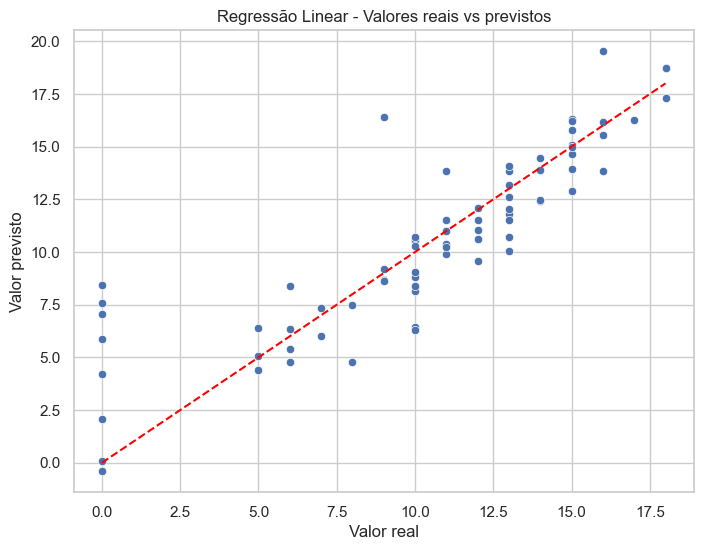

In [63]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_pred)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red",
    linestyle="--"
)

plt.xlabel("Valor real")
plt.ylabel("Valor previsto")
plt.title("Regressão Linear - Valores reais vs previstos")
plt.show()

In [64]:
coeficientes = pd.DataFrame({
    "Variavel": X.columns,
    "Coeficiente": modelo.coef_
}).sort_values(by="Coeficiente", ascending=False)

display(coeficientes.head(10))
display(coeficientes.tail(10))

,Variavel,Coeficiente
3,traveltime_mat,1.691885
21,Dalc_por,1.564096
10,Walc_mat,1.419368
43,schoolsup_mat_yes,1.310672
46,activities_mat_yes,1.285494
11,health_mat,0.946823
58,romantic_por_yes,0.930993
14,G2_mat,0.911751
54,famsup_por_yes,0.807496
52,guardian_por_other,0.572528


,Variavel,Coeficiente
38,reason_home,-0.402802
4,studytime_mat,-0.404764
44,famsup_mat_yes,-0.631060
23,health_por,-0.943010
53,schoolsup_por_yes,-0.983154
50,romantic_mat_yes,-1.023340
22,Walc_por,-1.256762
56,activities_por_yes,-1.587084
15,traveltime_por,-1.730214
9,Dalc_mat,-1.743623


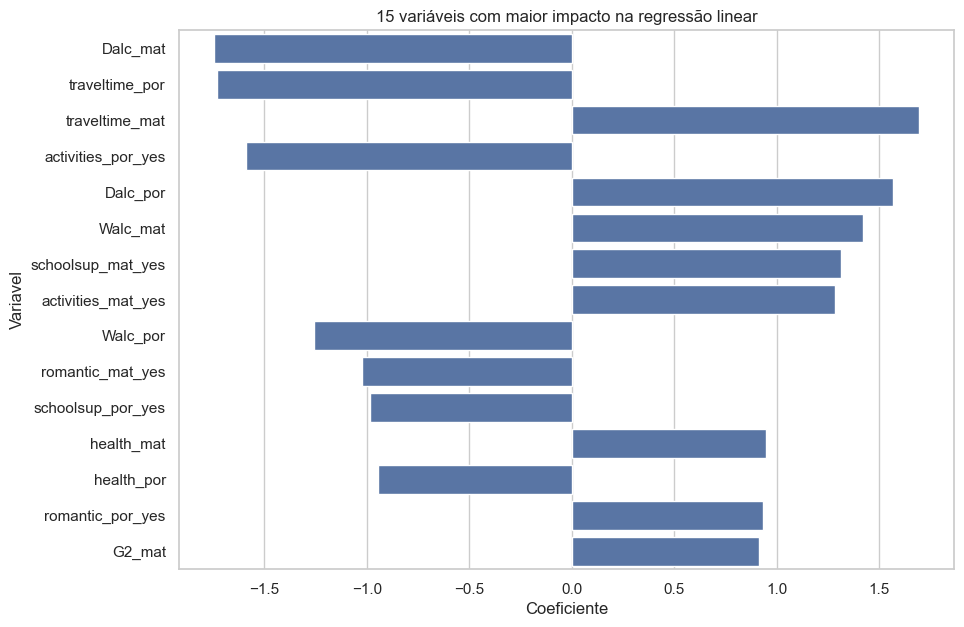

In [65]:
top_coef = coeficientes.reindex(
    coeficientes["Coeficiente"].abs().sort_values(ascending=False).index
).head(15)

plt.figure(figsize=(10, 7))
sns.barplot(data=top_coef, x="Coeficiente", y="Variavel")
plt.title("15 variáveis com maior impacto na regressão linear")
plt.show()